# Setting up a basic ReAct Agent in LangGraph

In [10]:
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env

True

In [2]:
# Load Brave Search tool for the ReAct agent
import os
from langchain_community.tools.brave_search.tool import BraveSearch

brave_api_key = os.getenv("BRAVE_SEARCH_API_KEY") or os.getenv("BRAVESearch_API_KEY")
if not brave_api_key:
    raise ValueError(
        "Missing Brave API key. Set BRAVE_SEARCH_API_KEY in your .env file."
    )

tools = [
    BraveSearch.from_api_key(api_key=brave_api_key)
 ]

In [4]:
# Display the loaded tools to verify what tools are available for the ReAct agent
# This will show the tool name, description, and function details
print(tools[0].name)
print(tools[0].description)

brave_search
a search engine. useful for when you need to answer questions about current events. input should be a search query.


In [5]:
tools[0].run('weather in LA')

'[{"title": "NWS Forecast Office Los Angeles, CA", "link": "https://www.weather.gov/lox/", "snippet": "Last Map Update: Thu, Mar 5, 2026 at 3:36:22 pm PST ... Potential Impacts: Localized downed trees Localized power outages Hazardous driving conditions with crosswinds &amp; road debris Hazardous seas, including nearshore and near the islands \\u00b7 Read More... ... US Dept of Commerce National Oceanic and Atmospheric Administration National Weather Service Los Angeles, CA 520 North Elevar Street Oxnard, CA 93030 805-988-6610 Comments? Last Map Update: Thu, Mar 5, 2026 at 3:36:22 pm PST ... Potential Impacts: Localized downed trees Localized power outages Hazardous driving conditions with crosswinds & road debris Hazardous seas, including nearshore and near the islands \\u00b7 Read More... ... US Dept of Commerce National Oceanic and Atmospheric Administration National Weather Service Los Angeles, CA 520 North Elevar Street Oxnard, CA 93030 805-988-6610 Comments?"}, {"title": "Los Ang

In [11]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from datetime import datetime

today = datetime.today().strftime("%B ") + str(datetime.today().day) + ("th" if 11<=datetime.today().day<=13 else {1:"st",2:"nd",3:"rd"}.get(datetime.today().day%10,"th")) + datetime.today().strftime(", %Y")
print(today)

llm = ChatOpenAI(model="gpt-4.1-mini")
agent_executor = create_agent(
    llm, tools, system_prompt=f'Today is {today}')  # true as of today :)

March 6th, 2026


In [6]:
response = agent_executor.invoke(
    {"messages": [("user", "Who is the current Ravens QB?")]})

In [7]:
response['messages'][-1].content

'The current quarterback (QB) for the Baltimore Ravens is Lamar Jackson. There is also a mention of Tyler Huntley as a quarterback on the team, but Lamar Jackson is the primary and well-known starting QB.'

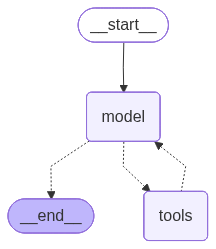

In [8]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [9]:
response = agent_executor.invoke({"messages": [("user", "Tell me about the laws around the world. All of them. No questions just start googling")]})

print(response['messages'][-1].content)

Laws around the world vary widely, encompassing everything from everyday rules to very specific or unusual regulations. Here are some examples of diverse and interesting laws from different countries:

- Singapore has a ban on selling or importing chewing gum except for medical purposes, implemented to maintain cleanliness.
- In some parts of Greece, wearing high heels at ancient sites is illegal to protect the structures.
- Certain French towns have laws making it illegal to die there, a symbolic measure related to cemetery capacity.
- In Thailand, specific rules govern clothing, including underwear regulations.
- In Scotland, you must let anyone use your toilet if they ask, under certain conditions.
- Samoa prohibits certain activities such as holding salmon under suspicious circumstances.
- Various places have restrictions on behaviors such as jaywalking (Germany), feeding birds (Venice), or wearing high heels (certain locations).

There are also numerous unusual local laws, such as

In [10]:
response

{'messages': [HumanMessage(content='Tell me about the laws around the world. All of them. No questions just start googling', additional_kwargs={}, response_metadata={}, id='68fe8588-5a34-4d74-852f-9f3002f350b8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 96, 'total_tokens': 114, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_828130e5d4', 'id': 'chatcmpl-DGQzERLxXZptz5d5DmIdJVqYYfafB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cc3ac-008c-7e92-9c75-91ec500de7fb-0', tool_calls=[{'name': 'Search', 'args': {'__arg1': 'laws around the world'}, 'id': 'call_fFqMloGyP13ikKDos6TFRPuX', 'type': 'tool_cal

In [11]:
for message in response['messages']:
    print(f"\n{message.__class__.__name__}:")
    if hasattr(message, 'content') and message.content:
        print(f"  Content: {message.content}")
    if hasattr(message, 'tool_calls') and message.tool_calls:
        print(f"  Tool Calls: {message.tool_calls}")


HumanMessage:
  Content: Tell me about the laws around the world. All of them. No questions just start googling

AIMessage:
  Tool Calls: [{'name': 'Search', 'args': {'__arg1': 'laws around the world'}, 'id': 'call_fFqMloGyP13ikKDos6TFRPuX', 'type': 'tool_call'}]

ToolMessage:
  Content: ["From restrictions against driving while wearing flip-flops to the three French towns where it's illegal to die, here are 40 obscure and just plain weird laws ...", "From underwear rules in Thailand to France's kissing ban, these are some of the world's quirkiest laws.", "1. Chewing gum is illegal in Singapore · 2. It's illegal to wear high heels in ancient sites in Greece · 3. In Western Australia, it was illegal ...", 'Discover weird laws around the world, including weird laws in the US (like bouncing pickles!), weird laws in Canada, the UK, Australia, Singapore and more.', "1. It's Illegal to hold Salmon under Suspicious Circumstances · 2. You Must let Anyone use your Toilet if they ask in Scotlan

# Giving Our Agent Short Term Memory

In [12]:
from langgraph.graph import MessagesState, END, StateGraph, START
from langchain_core.messages import HumanMessage, AIMessage


In [13]:
agent_executor.invoke({"messages": [("user", "Hi I am Sinan")]})['messages'][-1].content

'Hello Sinan! How can I assist you today?'

In [14]:
agent_executor.invoke({"messages": [("user", "What is my name?")]})['messages'][-1].content

"You haven't told me your name yet. If you'd like, you can share it with me!"

In [15]:
from langgraph.checkpoint.memory import MemorySaver  # built in short term memory

In [16]:
llm = ChatOpenAI(model="gpt-4.1-mini")
short_term_memory_agent_executor = create_agent(
    llm, tools, system_prompt=f'Today is {today}',
    checkpointer=MemorySaver()
)

In [17]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="Hi I am Sinan")]},
    config={"configurable": {"thread_id": "thread_1"}}
)['messages'][-1].content

'Hello Sinan! How can I assist you today?'

In [18]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "thread_1"}}
)['messages'][-1].content

'Your name is Sinan. How can I help you further, Sinan?'

In [19]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "thread_2"}}
)['messages'][-1].content

"I don't have access to personal data about users unless you share it with me during the conversation. So, I don't know your name. If you'd like to tell me your name, I'd be happy to remember it for this conversation!"